# 🚗 License Plate Detector — YOLOv8 Training Notebook
### Train a custom license plate detection model using YOLOv8 + Roboflow dataset

**What this notebook does:**
1. Downloads the dataset from Roboflow
2. Trains YOLOv8 on the dataset
3. Evaluates the model
4. Downloads `best.pt` — ready to plug into the ANPR repo


## 1- Install Dependencies

In [ ]:
# Install YOLOv8 and Roboflow SDK
!pip install ultralytics roboflow -q

# Verify installation
import ultralytics
ultralytics.checks()

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.7/112.6 GB disk)


## 2- Download Dataset from Roboflow

We use the **License Plate Recognition** dataset (10,000+ images) — the same one used by the original ANPR repo author.


In [ ]:
from roboflow import Roboflow

# ⬇️  Paste your Roboflow API key here
API_KEY = "MryOo4qN7gTAgXbepxC0"

rf = Roboflow(api_key=API_KEY)

# Download the license plate dataset (same one used in original repo)
project = rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e")
dataset = project.version(4).download("yolov8")

print('\n✅ Dataset downloaded!')
print('📁 Location:', dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to License-Plate-Recognition-4 in yolov8:: 100%|██████████| 48488/48488 [00:09<00:00, 5001.37it/s]



✅ Dataset downloaded!
📁 Location: /content/License-Plate-Recognition-4


## 3- Inspect the Dataset

In [ ]:
import os
import yaml

# Find the data.yaml file
data_yaml_path = os.path.join(dataset.location, 'data.yaml')

with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print('📊 Dataset Summary:')
print('  Classes:', data_config.get('names'))
print('  Number of classes:', data_config.get('nc'))
print('  Train path:', data_config.get('train'))
print('  Val path:', data_config.get('val'))

# Count images
train_dir = os.path.join(dataset.location, 'train', 'images')
val_dir   = os.path.join(dataset.location, 'valid', 'images')

if os.path.exists(train_dir):
    print(f'\n  Training images:   {len(os.listdir(train_dir))}')
if os.path.exists(val_dir):
    print(f'  Validation images: {len(os.listdir(val_dir))}')

📊 Dataset Summary:
  Classes: ['License_Plate']
  Number of classes: 1
  Train path: ../train/images
  Val path: ../valid/images

  Training images:   21173
  Validation images: 2046


## 4- Preview Some Dataset Images

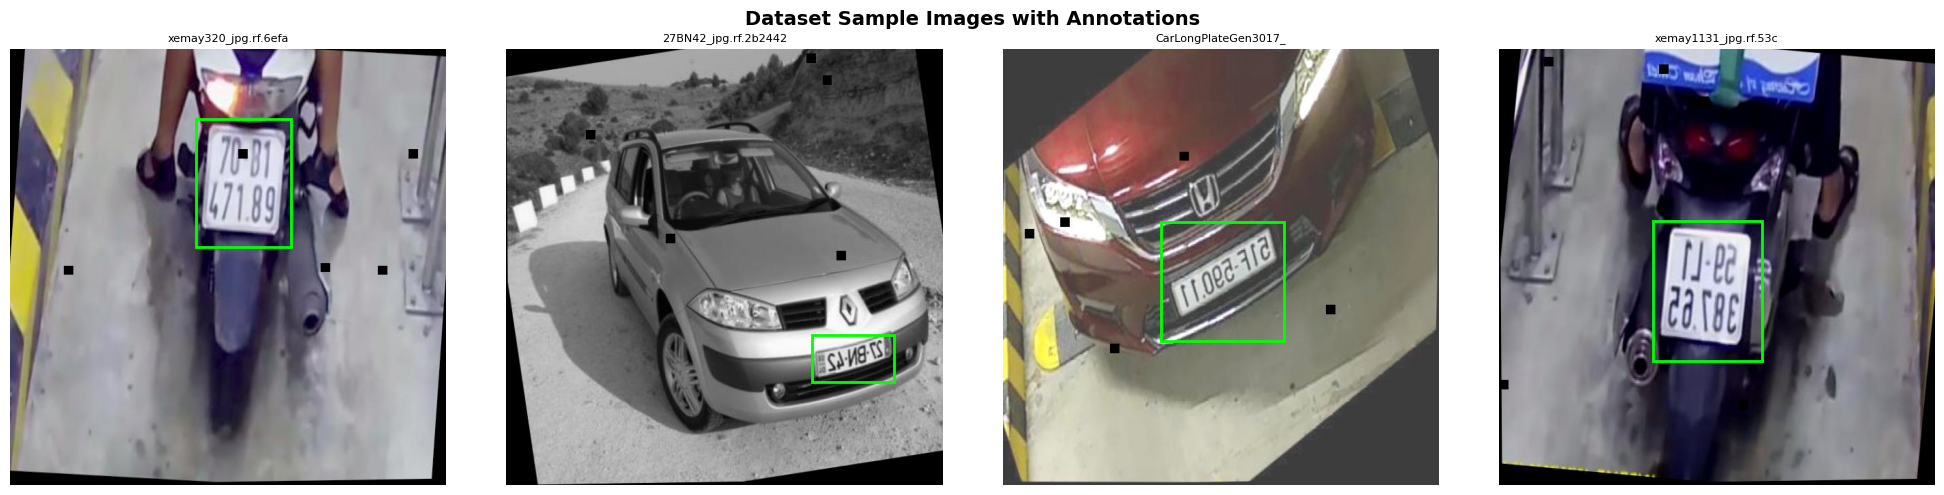

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random

def show_sample_images(image_dir, label_dir, num_samples=4):
    image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    samples = random.sample(image_files, min(num_samples, len(image_files)))

    fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))
    fig.suptitle('Dataset Sample Images with Annotations', fontsize=14, fontweight='bold')

    for ax, img_file in zip(axes, samples):
        img_path   = os.path.join(image_dir, img_file)
        label_path = os.path.join(label_dir, img_file.rsplit('.', 1)[0] + '.txt')

        img = Image.open(img_path)
        w, h = img.size
        ax.imshow(img)

        if os.path.exists(label_path):
            with open(label_path) as lf:
                for line in lf:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = map(float, parts)
                        x1 = (cx - bw / 2) * w
                        y1 = (cy - bh / 2) * h
                        rect = patches.Rectangle(
                            (x1, y1), bw * w, bh * h,
                            linewidth=2, edgecolor='lime', facecolor='none'
                        )
                        ax.add_patch(rect)

        ax.set_title(img_file[:20], fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

train_img_dir   = os.path.join(dataset.location, 'train', 'images')
train_label_dir = os.path.join(dataset.location, 'train', 'labels')
show_sample_images(train_img_dir, train_label_dir)

## 5- Model Training

We use **YOLOv8n** (nano) — fastest and lightest

 *You can always retrain with `yolov8s` if you want more accuracy.

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv8 nano model (downloads automatically)
model = YOLO('yolov8n.pt')

# ── Training config ──────────────────────────────────────────
EPOCHS   = 20    # increase to 150 for better accuracy
IMG_SIZE = 640    # standard YOLO input size
BATCH    = 16     # reduce to 8 if you get out-of-memory errors
# ─────────────────────────────────────────────────────────────

results = model.train(
    data    = data_yaml_path,
    epochs  = EPOCHS,
    imgsz   = IMG_SIZE,
    batch   = BATCH,
    name    = 'license_plate_detector',
    patience= 20,          # stop early if no improvement for 20 epochs
    device  = 0,           # use GPU
    verbose = True
)

print('\n✅ Training complete!')

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/License-Plate-Recognition-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=license_plate_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

## 6- Evaluation

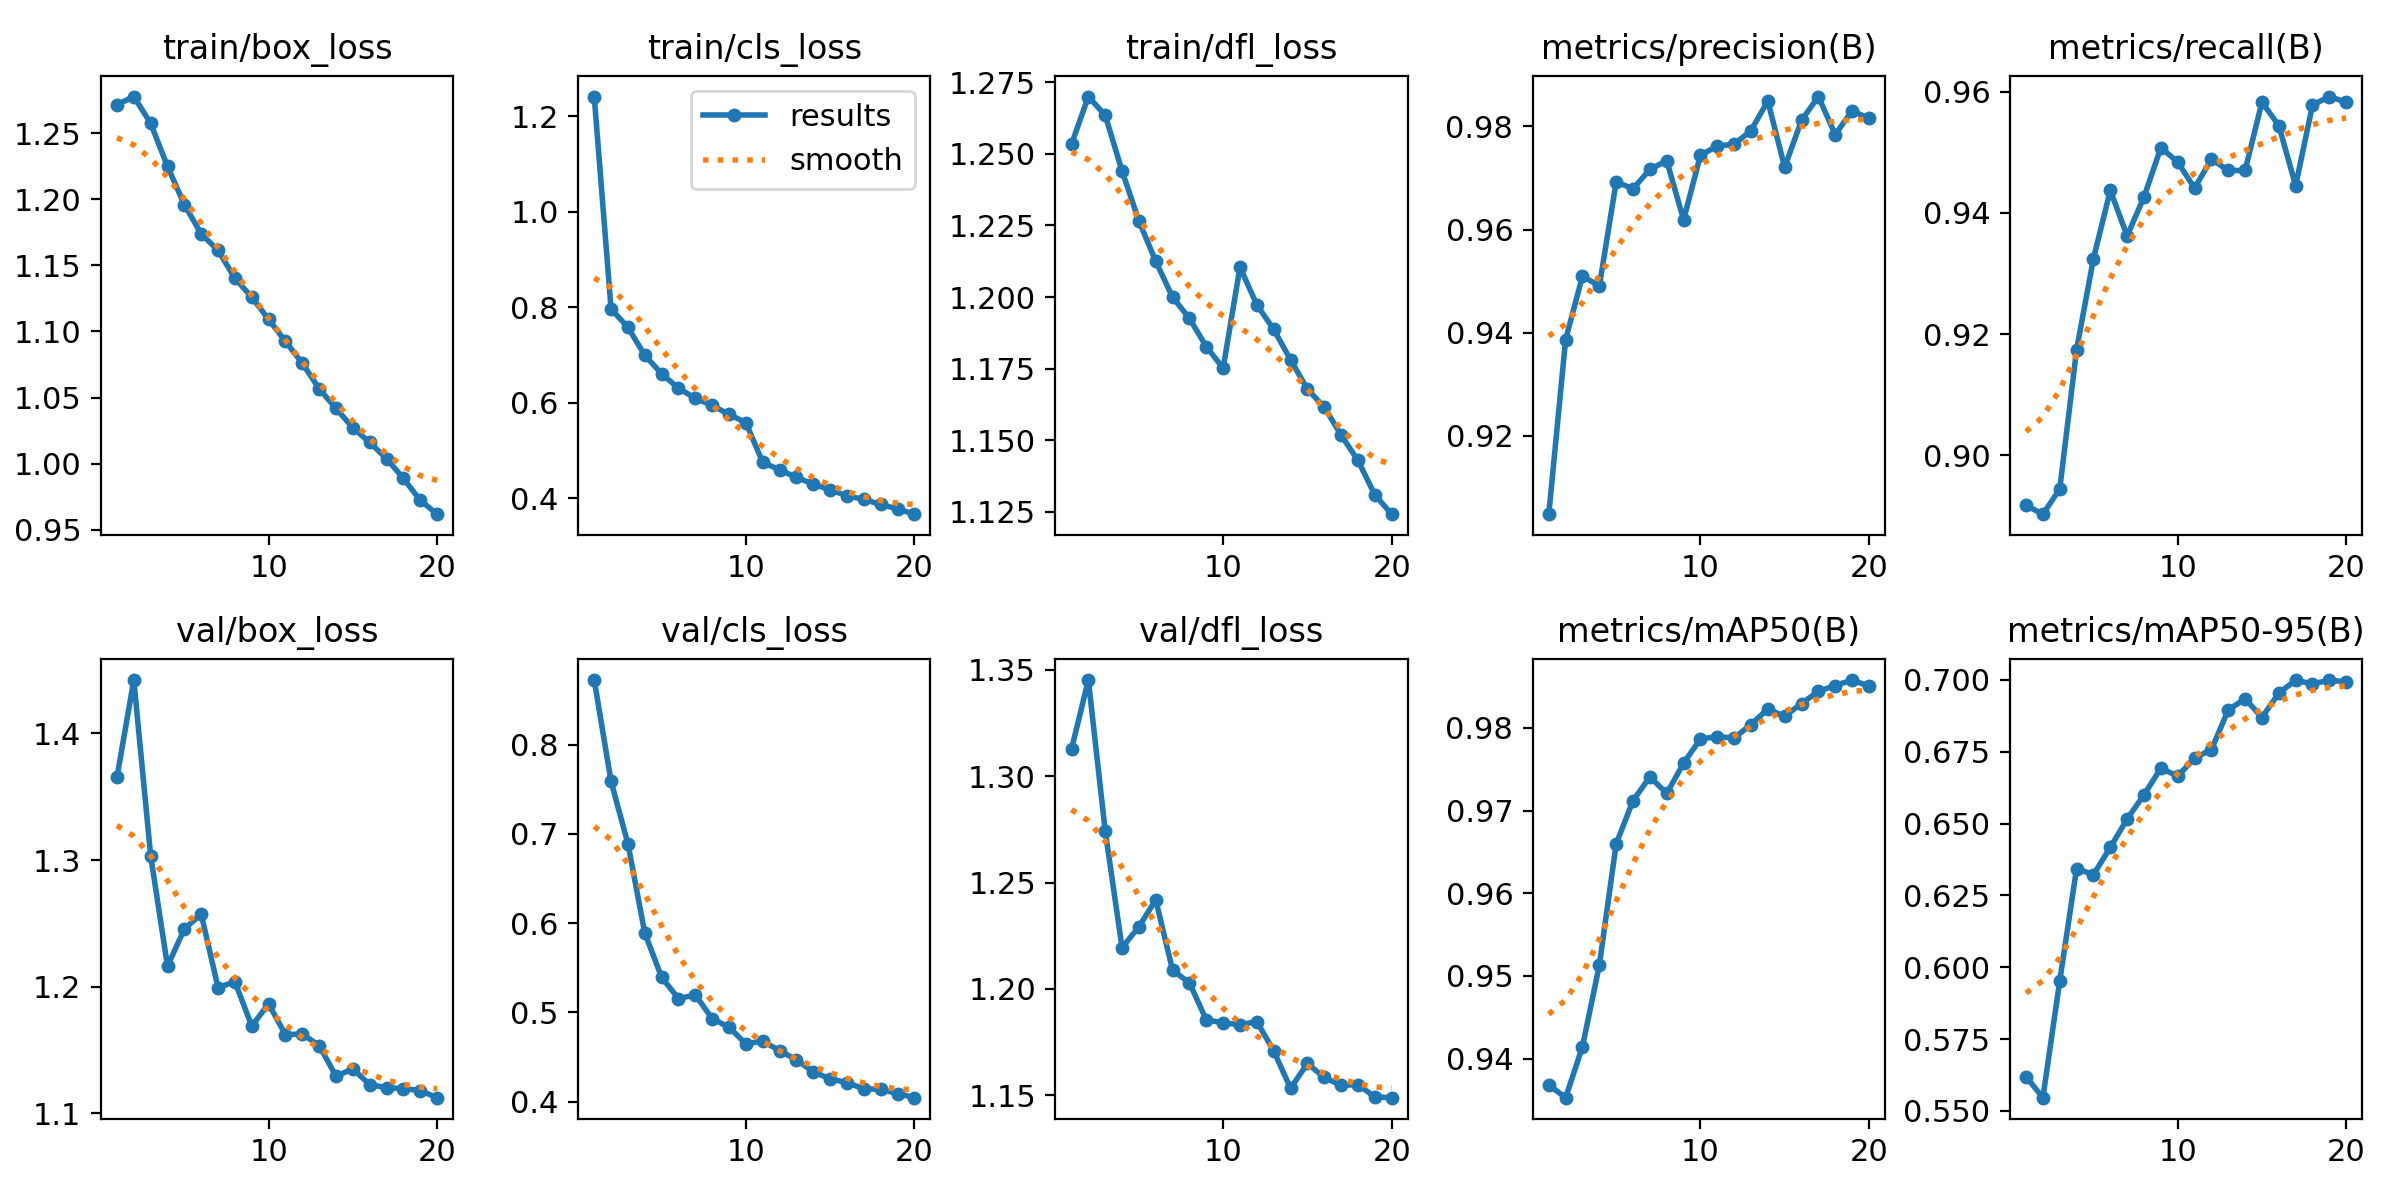

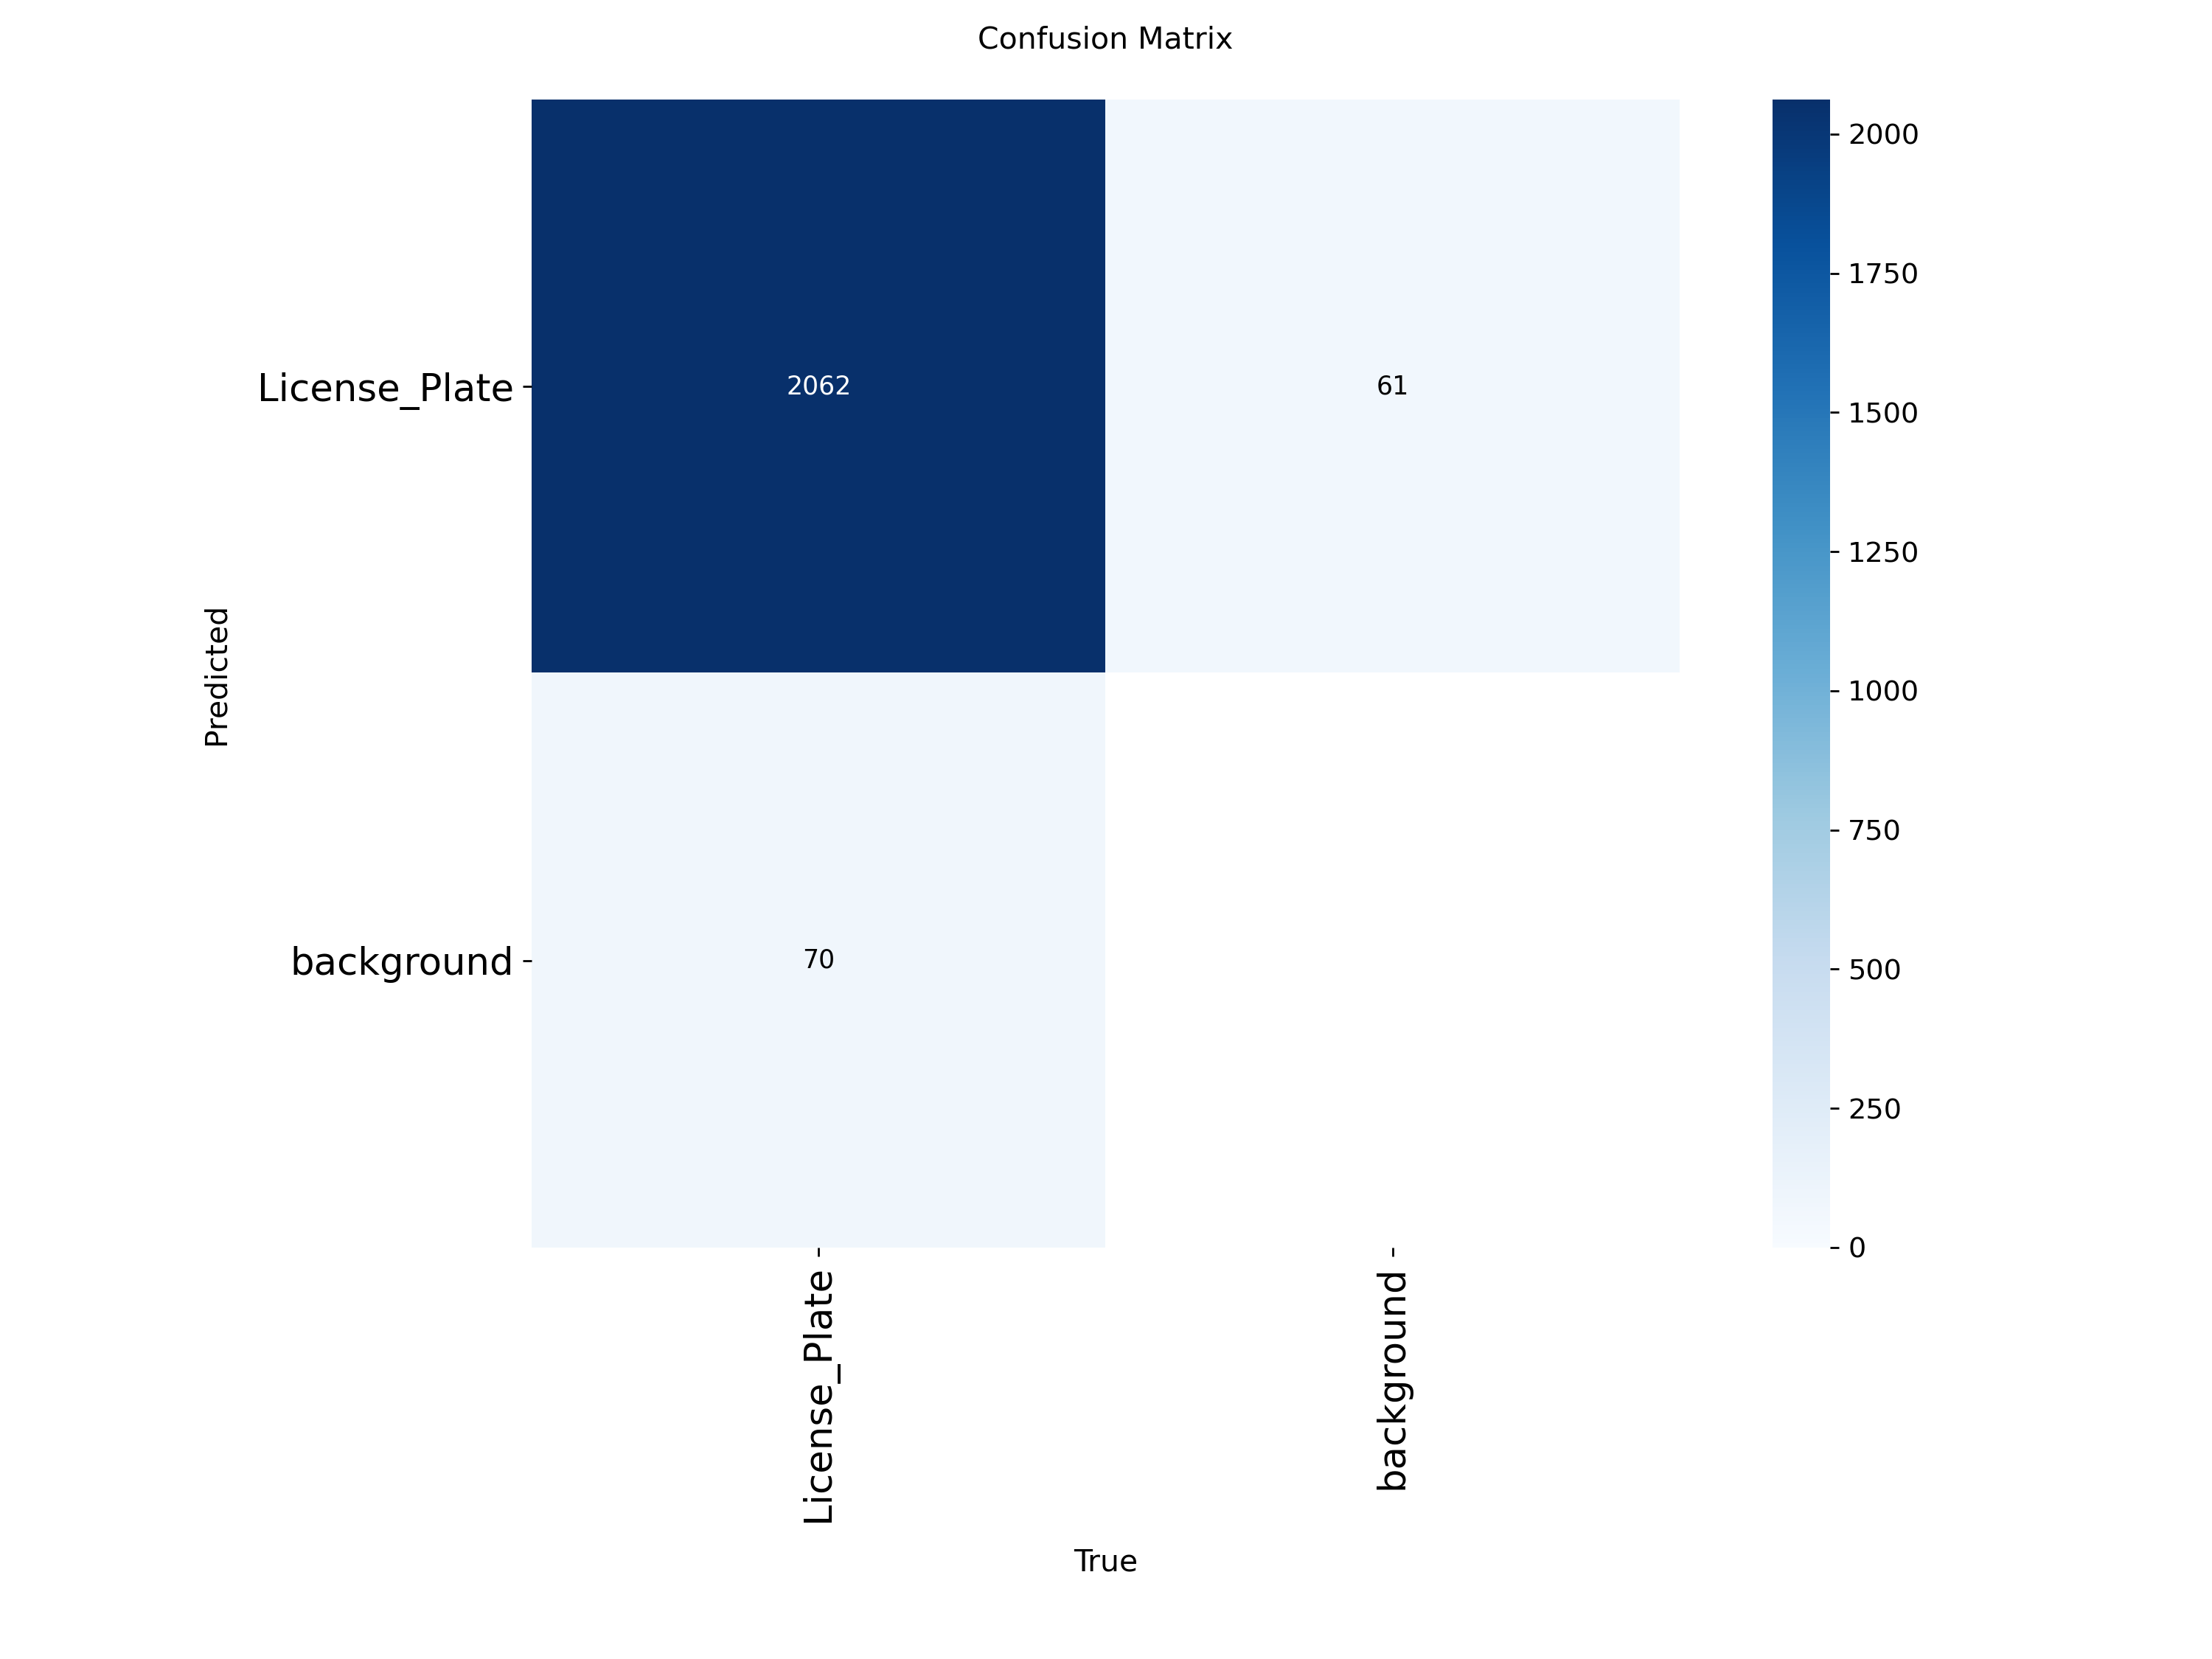

In [ ]:
# Show training curves (loss, precision, recall, mAP)
from IPython.display import Image as IPImage, display
import glob

# Find the results plot
results_plots = glob.glob('runs/detect/license_plate_detector/results.png')
if results_plots:
    display(IPImage(results_plots[0], width=900))

# Show confusion matrix
confusion_matrix = glob.glob('runs/detect/license_plate_detector/confusion_matrix.png')
if confusion_matrix:
    display(IPImage(confusion_matrix[0], width=600))

In [ ]:
# Run validation on the val set and print metrics
best_model = YOLO('runs/detect/license_plate_detector/weights/best.pt')
metrics = best_model.val(data=data_yaml_path)

print('\n📊 Validation Metrics:')
print(f'  mAP50:    {metrics.box.map50:.4f}')   # main metric — aim for > 0.85
print(f'  mAP50-95: {metrics.box.map:.4f}')
print(f'  Precision:{metrics.box.mp:.4f}')
print(f'  Recall:   {metrics.box.mr:.4f}')

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1132.3±373.0 MB/s, size: 34.5 KB)
val: Scanning /content/License-Plate-Recognition-4/valid/labels.cache... 2046 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2046/2046 858.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 6.5it/s 19.8s
                   all       2046       2132      0.982       0.96      0.986        0.7
Speed: 1.3ms preprocess, 3.7ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val

📊 Validation Metrics:
  mAP50:    0.9855
  mAP50-95: 0.7001
  Precision:0.9822
  Recall:   0.9603


## 7- Test on a sample


image 1/1 /content/License-Plate-Recognition-4/valid/images/pic_243_jpg.rf.722889928c72e1cd2eee6f2fce185fa8.jpg: 640x640 1 License_Plate, 8.3ms
Speed: 1.7ms preprocess, 8.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


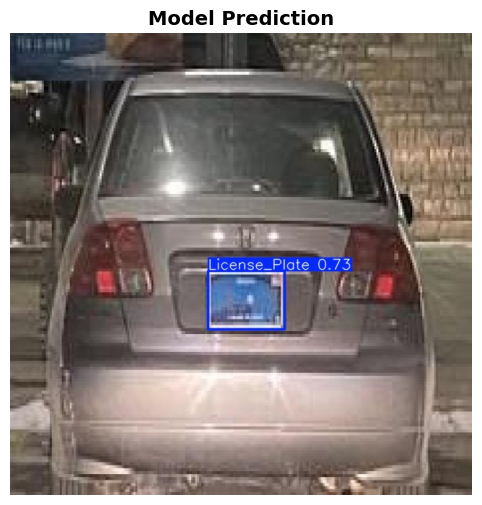

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random, os

# Pick a random validation image
val_images = [f for f in os.listdir(val_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
test_img   = os.path.join(val_dir, random.choice(val_images))

# Run inference
preds = best_model.predict(source=test_img, save=True, conf=0.5)

# Show result
result_path = preds[0].save_dir
saved_imgs  = os.listdir(result_path)
if saved_imgs:
    img = mpimg.imread(os.path.join(result_path, saved_imgs[0]))
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Model Prediction', fontsize=14, fontweight='bold')
    plt.show()

## 8- Download `best.pt`

This is the file you need to plug into the ANPR repo.

In [ ]:
from google.colab import files
import shutil

best_pt_path = 'runs/detect/license_plate_detector/weights/best.pt'

# Copy to root for easy access
shutil.copy(best_pt_path, '/content/license_plate_detector.pt')

# Download to your machine
files.download('/content/license_plate_detector.pt')

print('✅ best.pt downloaded!')
print('\n📌 Next step:')
print('  1. Place license_plate_detector.pt in the ANPR repo folder')
print('  2. In main.py, update this line:')
print('     license_plate_detector = YOLO(\'license_plate_detector.pt\')')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ best.pt downloaded!

📌 Next step:
  1. Place license_plate_detector.pt in the ANPR repo folder
  2. In main.py, update this line:
     license_plate_detector = YOLO('license_plate_detector.pt')


## 9- How to Use in the ANPR Repo

After downloading `license_plate_detector.pt`:

```
automatic-number-plate-recognition-python-yolov8/
├── main.py
├── util.py
├── add_missing_data.py
├── visualize.py
├── license_plate_detector.pt   ← place it here
└── sample.mp4                  ← your input video
```

In `main.py`, find these lines and update the model path:
```python
# Car detector (pretrained — no change needed)
coco_model = YOLO('yolov8n.pt')

# License plate detector — point to your trained model ✅
license_plate_detector = YOLO('license_plate_detector.pt')
```

Then run:
```bash
pip install ultralytics easyocr opencv-python filterpy scipy
python main.py
python add_missing_data.py
python visualize.py
